# Chapter 4. 데이터 표현과 특성 공학
- 데이터가 어떤 형태의 특성으로 구성되어 있는가보다 **데이터를 어떻게 표현하는가가 머신러닝 모델의 성능에 주는 영향이 큼**
- 특정 어플리케이션에 가장 적합한 데이터 표현을 찾는 것을 **특성 공학(feature engineering)이라 함**
- **올바른 데이터 표현은 지도 학습 모델에서 적절한 매개변수를 선택하는 것보다 성능에 더 큰 영향을 줌**

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)

print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

from sklearn.model_selection import train_test_split
#plt.rc('font', family="Apple SD Gothic Neo")

Python 버전: 3.11.5 (main, Sep 11 2023, 13:54:46) [GCC 11.2.0]
numpy 버전: 1.24.3
pandas 버전: 2.0.3
matplotlib 버전: 3.7.2
SciFy 버전: 1.11.1
IPython 버전: 8.15.0
scikit-learn 버전: 1.3.0


## 4.6 일변량(타깃 변수 1) 비선형 변환 (Univariate Nonlinear Transformations)
- **log, exp, sin 같은 수학 함수를 적용하는 방법도 특성 변환에 유용**, 특히 선형 모델과 신경망(각 특성의 스케일과 분포에 밀접한 영향)
- **대부분의 모델은 각 특성이 (회귀에서는 타깃도) 정규분포와 비슷할 때 최고의 성능을 보임**
- 이런 변환이 도움되는 전형적인 경우는 정수 카운트 데이터를 다룰 때 -> **방열 EP 소재 직경 분포에 적용해보자!**

In [4]:
rnd = np.random.RandomState(0)

X_org = rnd.normal(size=(1000,3)) # 정규 분포
w = rnd.normal(size=3)

X = rnd.poisson(10*np.exp(X_org)) # 1000 X 3의 X 배열 생성, 정규분포 -> 푸아송 분포
y = np.dot(X_org, w) # 1000 X 1의 일변량 타깃값 생성, 정규 분포

print(X[:10, 0])

[ 56  81  25  20  27  18  12  21 109   7]


- **카운트 데이터의 전형적인 분포는 푸아송(Poisson) 분포임**
- 푸아송 분포는 단위 시간 안에 일어날 이벤트 횟수를 표현하는 확률 분포임
- 해당 예시에서는 타깃값을 만들기 위해 먼저 정규 분포를 만들고 그 다음 poisson 함수를 적용

> - X 내 1열에서 각 양의 정수들이 나타난 횟수를 세보자

In [7]:
np.bincount(X[:,0]) # bincount는 항상 0부터 시작하므로 아래에서 양의 정수 2가 총 68번 나온것으로 해석함 -> X[:,1]과 X[:,2] 특성도 비슷함

array([28, 38, 68, 48, 61, 59, 45, 56, 37, 40, 35, 34, 36, 26, 23, 26, 27,
       21, 23, 23, 18, 21, 10,  9, 17,  9,  7, 14, 12,  7,  3,  8,  4,  5,
        5,  3,  4,  2,  4,  1,  1,  3,  2,  5,  3,  8,  2,  5,  2,  1,  2,
        3,  3,  2,  2,  3,  3,  0,  1,  2,  1,  0,  0,  3,  1,  0,  0,  0,
        1,  3,  0,  1,  0,  2,  0,  1,  1,  0,  0,  0,  0,  1,  0,  0,  2,
        2,  0,  1,  1,  0,  0,  0,  0,  1,  1,  0,  0,  0,  0,  0,  0,  0,
        1,  0,  0,  0,  0,  0,  1,  1,  0,  0,  1,  0,  0,  0,  0,  0,  0,
        0,  1,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1])

> - 선형 모델은 이런 poisson 분포 데이터를 잘 처리하지 못함, 아래 리지 회귀 예시

In [11]:
from sklearn.linear_model import Ridge
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
score = Ridge().fit(X_train, y_train).score(X_test, y_test)
score

0.6224186236310756

> - **위 X 데이터를 log 함수를 적용하여 변환하면 점수 향상에 도움이 됨**

In [13]:
X_train_log = np.log(X_train + 1) # 1을 더해주는 이유는 기존 X에 있는 0값이 log을 취하면서 음의 무한대로 발산하기 때문임
X_test_log = np.log(X_test + 1)

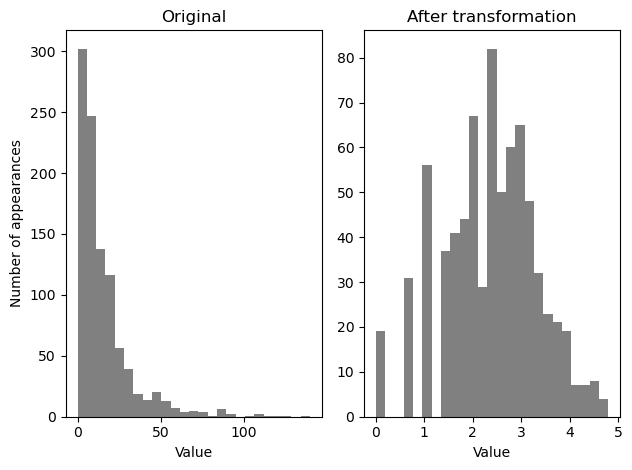

In [16]:
plt.subplot(1,2,1)
plt.hist(X[:,0], bins=25, color='grey')
plt.title('Original')
plt.ylabel('Number of appearances')
plt.xlabel('Value')

plt.subplot(1,2,2)
plt.hist(X_train_log[:,0], bins = 25, color='grey')
plt.title('After transformation')
plt.xlabel('Value')

plt.tight_layout()
plt.show()

In [17]:
score = Ridge().fit(X_train_log, y_train).score(X_test_log, y_test)
score

0.8749342372887815

- **데이터셋과 모델의 조합에 최적인 변환 방법을 찾기란 예술에 가까운 일**
- 특성마다 표현형이 다르므로 일부 특성만 변환하거나 특성마다 다른 전처리가 필요함
- **상황에 따라 타깃 변수 y를 변환하는 것이 좋을때도 있음(카운트를 예측하는 경우 log(y+1)을 활용하여 변환)**

- 구간 분활, 다항식, 상호작용은 데이터가 주어진 상황에서 모델의 성능에 큰 영향을 줄 수 있음, 특히 선형모델이나 나이브베이즈 모델
- **트리 기반 모델은 스스로 중요한 상호작용을 찾아낼 수 있고 대부분의 경우 데이터를 명시적으로 변환하지 않아도 됨**
- **SVM, 최근접이웃, 신경망 같은 모델은 이따금 구간 분활, 상호작용, 다항식으로 이득을 볼 수 있지만, 선형 모델 보다는 영향이 그렇게 뚜렷하지 않음**

## 4.7 특성 자동 선택
- 일반적으로 특성이 추가되면 모델은 더 복잡해지고 과대 적합될 가능성이 높아짐
- **새로운 특성을 추가하거나 고차원 데이터셋을 사용할 때, 가장 유용한 특성만 선택하고 나머지는 무시해서 특성 수를 줄이는 것이 좋음 -> 일반화 성능 향상**
- 어떤 특성을 선택할지에 대한 방법:
> - **일변량 통계(univariate statstics), 모델 기반 선택(model-based selection), 반복적 선택(iterative selection)**
> - 위 방법들은 모두 지도학습 방법이므로 최적값을 찾으려면 타깃 값이 필요
> - **데이터를 훈련 세트와 테스트 세트로 나눈 다음, 훈련 데이터만 특성 선택에 사용해야 함(정보누설 방지)**

### 4.7.1 일변량 통계

- 일변량 통계에서는 개개의 특성과 타깃 사이에 중요한 통계적 관계가 있는지를 계산
- **통계 분석을 통해 깊게 관련되어 있다고 판단되는 특성을 선택**
- 분류에서는 분산분석(ANOVA, analysis of variance)
> - **분산분석은 데이터를 클래스별로 나누어 평균을 비교하는 방법**
> - 어떤 특성의 F-값이 높으면 그 특성은 클래스멸 평균이 서로 다르다는 뜻
- 이 방법의 핵심 요소는 **일변량**, **즉 각 특성이 독립적으로 평가된다는 점, 다른 특성과 깊게 연관된 특성은 선택되지 않음**
- **장점:**
> - 계산이 매우 빠르고 평가를 위해 모델을 만들 필요가 없음
> - 특성을 선택한 후 적용하려는 모델에 상관없이 사용할 수 있음

- **알고리즘 및 매개변수**
> - **분류에서는 f_classif(기본값), 회귀에서는 f_regression을 보통 선택**
> - 계산한 p-값에 기초하여 특성을 제외하는 방식을 선택, 계산식은 교재내 주석 참고
> - 매우 높은 p-값을 가진(즉, 타깃 값과 연관성이 작은) 특성을 제외할 수 있도록 **임계값을 조정하는 매개변수 사용**
> - ***SelectKBest***: 고정된 K개의 특성을 선택, ***SelectPercentile***: 지정된 비율만큼 특성을 선택

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

# 고정된 난수를 발생
rng = np.random.RandomState(42)
noise = rng.normal(size=(len(cancer.data), 50))

noise.shape

(569, 50)

In [ ]:
# 데이터에 노이즈 특성을 추가
# 처음 30개는 원본 특성이고 다음 50개는 노이즈가 됨
X_w_noise = np.hstack([cancer.data, noise])
X_w_noise.shape

(569, 80)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_w_noise, cancer.target, random_state=0, test_size=0.5)

# f_classif(기본값)와 SelectPercentile을 사용하여 특성의 50%를 선택
select = SelectPercentile(score_func=f_classif, percentile=50)
select.fit(X_train, y_train)

# 훈련 세트에 적용
X_train_selected = select.transform(X_train)

print(X_train.shape)
print(X_train_selected.shape)

(284, 80)
(284, 40)


> - ***get_support*** 메서드는 선택된 특성을 불리언 값으로 표시해주어 어떤 특성이 선택되었는지 확인 가능

[ True  True  True  True  True  True  True  True  True False  True False
  True  True  True  True  True  True False False  True  True  True  True
  True  True  True  True  True  True False False False  True False  True
 False False  True False False False False  True False False  True False
 False  True False  True False False False False False False  True False
  True False False False False  True False  True False False False False
  True  True False  True False False False False]


([<matplotlib.axis.YTick at 0x7f485ba12210>], [Text(0, 0, '0')])

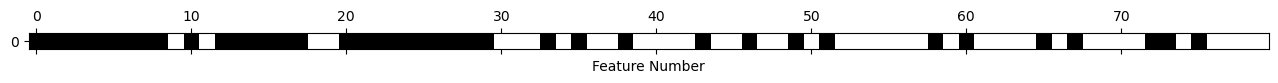

In [ ]:
mask = select.get_support()
print(mask)
# True는 검은색, False는 흰색으로 마스킹 수행
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel('Feature Number')
plt.yticks([0])

In [ ]:
# 전체 특성을 이용했을 때와 선택된 특성만 사용했을 때 로지스틱 회귀의 성능을 비교
from sklearn.linear_model import LogisticRegression

# 테스트 데이터 변환
X_test_selected = select.transform(X_test)

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
print('전체 특성 사용 점수:{:.3f}'.format(lr.score(X_test, y_test)))

lr.fit(X_train_selected, y_train)
print('선택된 일부 특성 사용 점수:{:.3f}'.format(lr.score(X_test_selected, y_test)))

전체 특성 사용 점수:0.951
선택된 일부 특성 사용 점수:0.933


### 4.7.2 모델 기반 특성 선택
- **지도 학습 ML 모델을 사용하여 특성의 중요도를 평가해서 가장 중요한 특성들만 선택**
- 최종적으로 사용할 지도 학습 모델과 같을 필요가 없음
- 일변량 분석과는 반대로 모델 기반 특성 선택은 **한번에 모든 특성을 고려하므로(사용된 모델이 상호작용을 잡아낼 수 있다면) 상호작용 부분을 반영할 수 있음**
- 선택을 위한 지도학습 모델에 따라 매우 복잡하고 일변량 분석보다는 훨씬 강력한 방법이 될 수 있음

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
select = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42), threshold='median')

- ***SelectFromModel*은 중요도가 지정한 임계치(threshold)보다 큰 모든 특성을 선택**
- L1 규제가 없는 모델을 사용할 경우 SelectFromModel의 threshold 매개변수의 기본값은 평균값을 나타내는 'mean'임
- '1.2*median', '1.3*mean'처럼 중간값과 평균값의 비율로 나타낼 수 있음

In [ ]:
select.fit(X_train, y_train)
X_train_l1 = select.transform(X_train)
print(X_train.shape)
print(X_train_l1.shape)

(284, 80)
(284, 40)


[ True  True  True  True  True  True  True  True  True  True  True False
  True  True False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True False  True False False  True False
 False False False False  True False False  True False  True  True False
 False False  True False False  True  True False False False False False
 False  True False False False False False False False  True False False
 False  True False False False False False False]


([<matplotlib.axis.YTick at 0x7f485b8189d0>], [Text(0, 0, '0')])

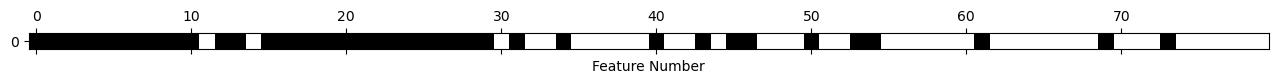

In [ ]:
mask = select.get_support()
print(mask)
# True는 검은색, False는 흰색으로 마스킹 수행
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel('Feature Number')
plt.yticks([0])

In [ ]:
# 테스트 데이터 변환
X_test_l1 = select.transform(X_test)

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
print('전체 특성 사용 점수:{:.3f}'.format(lr.score(X_test, y_test)))

lr.fit(X_train_l1, y_train)
print('선택된 일부 특성 사용 점수:{:.3f}'.format(lr.score(X_test_l1, y_test)))

전체 특성 사용 점수:0.951
선택된 일부 특성 사용 점수:0.947


### 4.7.3 반복적 특성 선택
- **반복적 특성 선택에서는 특성의  수가 각기 다른 일련의 모델을 만들어 특성 선택**, 계산 비용이 훨씬 많이 들어감
- 1. 특성을 하나도 선택하지 않은 상태에서 하나씩 추가(forward)
- 2. **모든 특성을 가지고 시작해서 어떤 종료 조건이 될 때까지 특성을 하나씩 제거(backward)**, 대표적으로 재귀적 특성 제거(RFE, reculsive feature elmination)
- ***SequentialFeatureSelector* 클래스는 *scoring* 매개변수에 지정된 측정 지표와 교차 검증 점수를 기준으로 특성을 하나씩 추가하거나 제거**
> - *scoring* 매개변수의 기본값은 회귀의 경우에는 R2, 분류일 경우에는 정확도
> - *direction* 매개변수가 'forward'일 경우 전진선택법(기본값), 'backward'일때 후진선택법을 수행

([<matplotlib.axis.YTick at 0x7f485b4ede50>], [Text(0, 0, '0')])

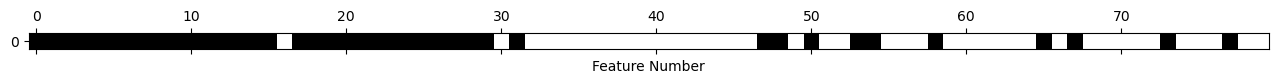

In [ ]:
from sklearn.feature_selection import RFE
select = RFE(RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=40)

select.fit(X_train, y_train)
# 선택된 특성을 표시
mask = select.get_support()
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel('Feature Number')
plt.yticks([0])

In [ ]:
# 해당 특성 선택시 로지스틱회귀 정확도 확인
X_train_rfe = select.transform(X_train)
X_test_rfe = select.transform(X_test)

score = LogisticRegression(max_iter=5000).fit(X_train_rfe, y_train).score(X_test_rfe, y_test)
print('선택된 일부 특성 사용 점수:{:.3f}'.format(score))

선택된 일부 특성 사용 점수:0.940


In [ ]:
# RFE 사용된 모델(RandomForest) 이용해서도 예측
# 이 경우 특성 선택을 위해 고려되었던 전체 모델이 아닌 최종 선택된 특성만 사용됨

print('테스트 점수:{:.3f}'.format(select.score(X_test, y_test)))

테스트 점수:0.951


- RFE 안에 있는 랜덤포레스트의 성능이 이 모델에서 선택한 특성으로 만든 로지스틱회귀의 성능과 같음, 다른 말로 하면 **특성 선택이 제대로 되면 선형 모델의 성능은 랜덤 포레스트와 견줄만함**

## 4.8 전문가 지식 활용
- '자전거 대여' 문제 예시

In [ ]:
# 2015년 8월 데이터를 pandas의 DataFrame으로 읽어 들이고 세 시간 간격으로 데이터를 다시 나누어 주요 경향 예측
citibike = mglearn.datasets.load_citibike()
citibike.head()

/home/1d78c05e-3e91-4b07-80d5-6517be9590e4/.local/lib/python3.11/site-packages/mglearn/datasets.py:57: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  data_resampled = data_starttime.resample("3h").sum().fillna(0)


starttime
2015-08-01 00:00:00     3
2015-08-01 03:00:00     0
2015-08-01 06:00:00     9
2015-08-01 09:00:00    41
2015-08-01 12:00:00    39
Freq: 3H, Name: one, dtype: int64

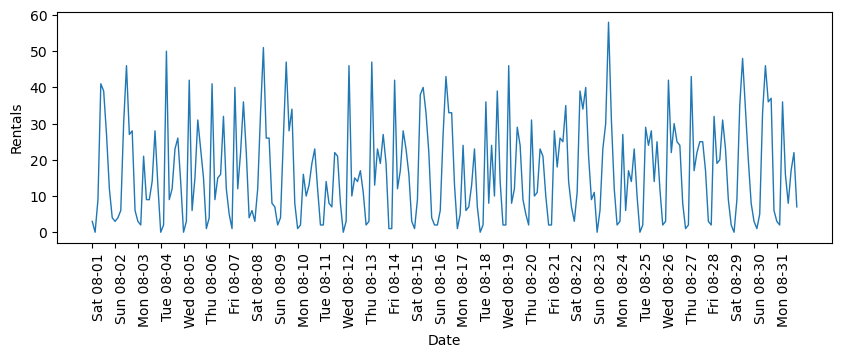

In [ ]:
# 8월 한 달 동안의 대여 횟수 그래프 표현
plt.figure(figsize=(10,3))
xticks = pd.date_range(start=citibike.index.min(), end=citibike.index.max(), freq='D')
week = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
xticks_name = [week[int(w)]+d for w, d in zip(xticks.strftime('%w'), xticks.strftime(' %m-%d'))]
plt.xticks(xticks, xticks_name, rotation=90, ha='left')
plt.plot(citibike, linewidth=1)
plt.xlabel('Date')
plt.ylabel('Rentals')
plt.show()

> - **컴퓨터에 날짜를 지정하는 일반적인 방법은 특정 시간으로부터 경과한 시간을 초로 나타내는 POSIX 시간임**

In [ ]:
# 타깃 값 추출(대여 횟수)
y = citibike.values
# POSIX 시간을 10**9로 나누어 변환, DatetimeIndex의 기본 단위는 나노초
X = citibike.index.astype('int64').values.reshape(-1,1)//10**9
print(X[0:10])
print(X.shape)

[[1438387200]
 [1438398000]
 [1438408800]
 [1438419600]
 [1438430400]
 [1438441200]
 [1438452000]
 [1438462800]
 [1438473600]
 [1438484400]]
(248, 1)


In [ ]:
# 처음 184개 데이터 포인트를 훈련 세트로 사용하고 나머지는 테스트 세트로 사용
n_train = 184

# 주어진 특성을 사용하여 평가하고 그래프를 만듭니다.
def eval_on_features(features, target, regressor):
    #훈련 세트와 테스트 세트로 나눔
    X_train, X_test = features[:n_train], features[n_train:]
    #타깃 값도 나눔
    y_train, y_test = target[:n_train], target[n_train:]
    regressor.fit(X_train, y_train)
    print('테스트 세트 R^2 :{:.2f}'.format(regressor.score(X_test, y_test)))
    y_pred = regressor.predict(X_test)
    y_pred_train = regressor.predict(X_train)
    plt.figure(figsize=(10,3))
    
    plt.xticks(range(0, len(X), 8), xticks_name, rotation=90, ha='left')
    
    plt.plot(range(n_train), y_train, label='Train')
    plt.plot(range(n_train, len(y_test)+n_train), y_test, '-', label='Test')
    plt.plot(range(n_train), y_pred_train, '--', label='Train_pred')
    
    plt.plot(range(n_train, len(y_test)+n_train), y_pred, '--', label='Test_pred')
    
    plt.legend(loc=(1.01,0))
    plt.xlabel('Date')
    plt.ylabel('Rentals')

테스트 세트 R^2 :-0.04


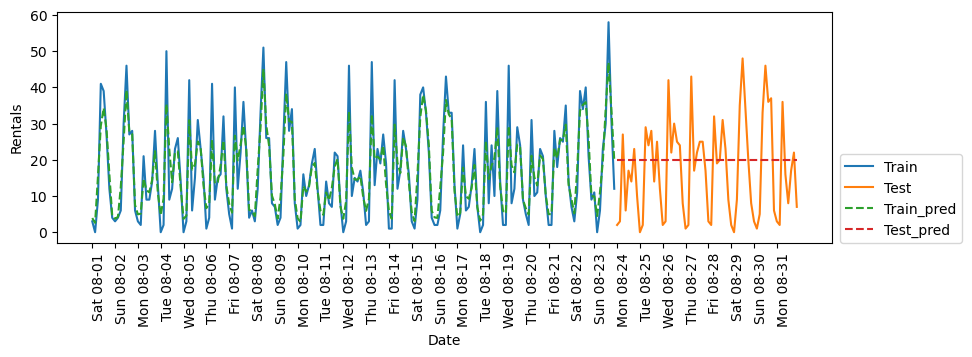

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100, random_state=0)
eval_on_features(X,y, regressor)

- 테스트 세트에 있는 POSIX 시간 특성의 값은 훈련 세트에 있는 특성 값의 범위 밖에 있음
- **트리 모델인 랜덤포레스트는 훈련 세트에 있는 특성의 범위 밖으로 외삽 할 수 있는 능력이 없음**

> - 훈련 데이터의 대여 데이터 그래프를 보면 **1. 시간, 2. 요일 이라는 두 요소가 중요**해보임, POSIX 시간은 제외

테스트 세트 R^2 :0.60


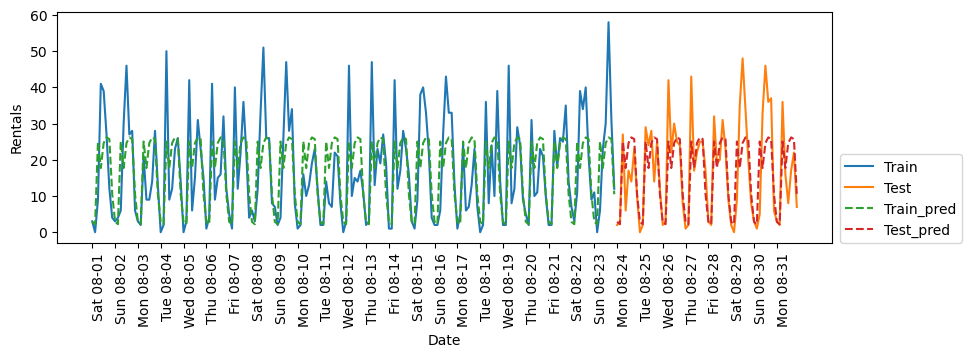

In [ ]:
# 시간 요소만 사용
X_hour = citibike.index.hour.values.reshape(-1,1)
eval_on_features(X_hour, y, regressor)

테스트 세트 R^2 :0.84


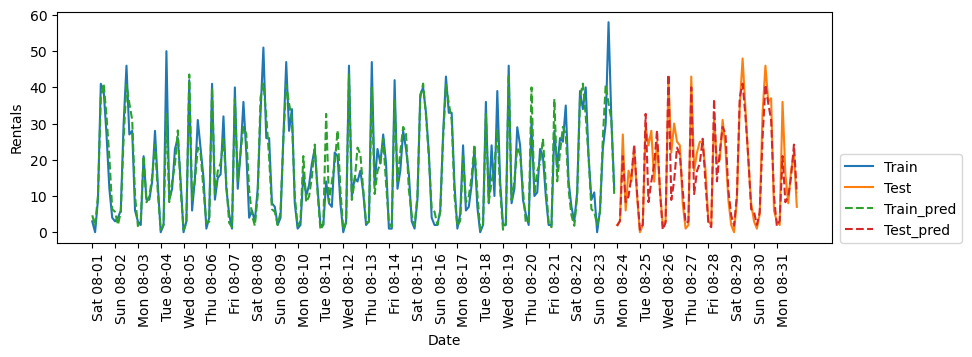

In [ ]:
# 위에서 요일 정보 추가
X_hour_week = np.hstack([citibike.index.dayofweek.values.reshape(-1,1),
                         citibike.index.hour.values.reshape(-1,1)])
eval_on_features(X_hour_week, y, regressor)

> - 이런 작업에 랜덤 포레스트 같이 복잡한 모델이 필요한 것은 아니므로 더 간단한 모델인 LinearRegression을 적용

테스트 세트 R^2 :0.13


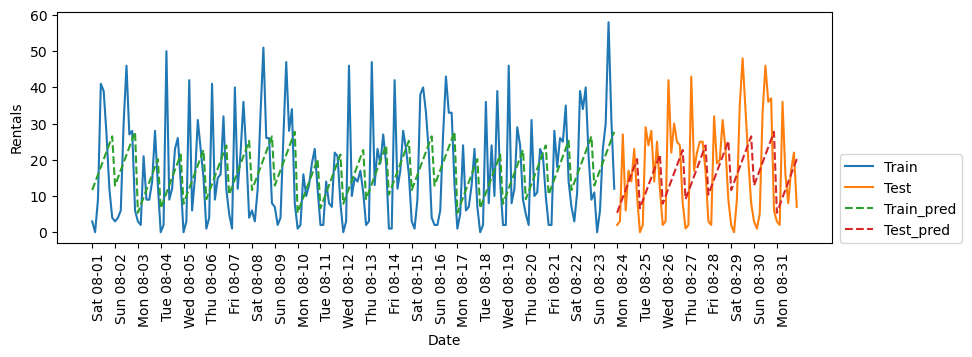

In [ ]:
from sklearn.linear_model import LinearRegression
eval_on_features(X_hour_week, y, LinearRegression())

- 요일과 시간이 정수로 인코딩되어 있어서 연속형 변수로 해석되기 때문에 예측도 떨어짐
- 선형 모델은 시간을 선형 함수로만 학습할 수 있어서, 하루에서 시간이 흐를수록 대여 수가 늘어나게 학습되었음

> - OneHotEncoder를 사용하여 정수형을 범주형 변수로 해석하도록 하여 예측도 향상 목표로 함

In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
X_hour_week_oh = enc.fit_transform(X_hour_week).toarray()
print(X_hour_week_oh)
print(X_hour_week_oh.shape)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 0. 1.]]
(248, 15)


테스트 세트 R^2 :0.62


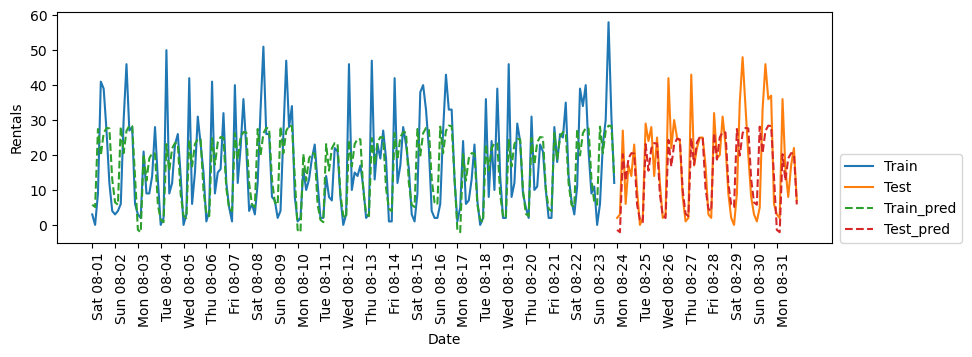

In [ ]:
eval_on_features(X_hour_week_oh, y, Ridge())

- **위 모델은 요일마다 하나의 계수를 학습하고, 시간마다도 하나의 계수를 학습 -> 시간 패턴이 모든 날에 걸쳐 공유 됨**

> - **상호작용 특성을 사용하면 시간과 요일의 조합별 계수를 학습할 수 있음**

테스트 세트 R^2 :0.85


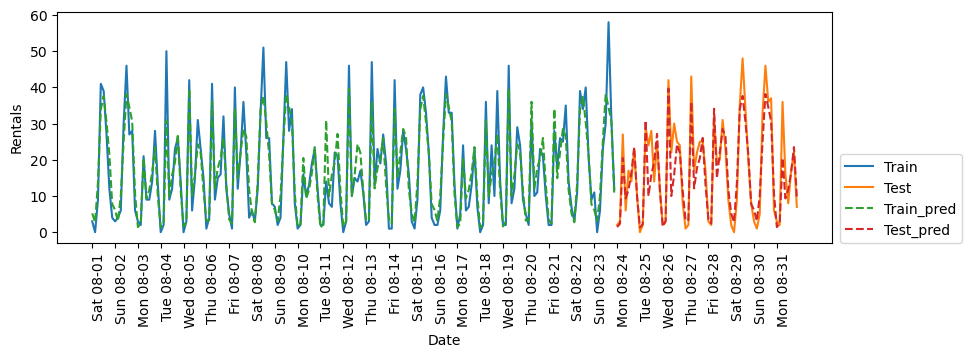

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly_transformer = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_hour_week_oh_poly = poly_transformer.fit_transform(X_hour_week_oh)
lr = Ridge()
eval_on_features(X_hour_week_oh_poly, y, lr)

- 랜덤포레스트와 거의 유사 성능 + 무엇이 학습되었는지가 명확함

> - 랜덤포레스트와 달리 이 모델이 학습한 계수를 그래프로 나타낼 수 있음

In [ ]:
# 먼저 시간과 요일 특성의 이름을 작성
hour = ['%02d:00' % i for i in range(0,24,3)]
print(hour)
day = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
print(day)
features = day + hour
print(features)

['00:00', '03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00']
['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun', '00:00', '03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00']


In [ ]:
# get_feature_names_out 메서드를 사용해 PolynomialFeatures로 추출한 모든 상호작용 특성에 이름을 달아줌
# 그리고 계수가 0이 아닌 특성만 선택함

features_poly = poly_transformer.get_feature_names_out(features)
print(features_poly)

['Mon' 'Tue' 'Wed' 'Thu' 'Fri' 'Sat' 'Sun' '00:00' '03:00' '06:00' '09:00'
 '12:00' '15:00' '18:00' '21:00' 'Mon Tue' 'Mon Wed' 'Mon Thu' 'Mon Fri'
 'Mon Sat' 'Mon Sun' 'Mon 00:00' 'Mon 03:00' 'Mon 06:00' 'Mon 09:00'
 'Mon 12:00' 'Mon 15:00' 'Mon 18:00' 'Mon 21:00' 'Tue Wed' 'Tue Thu'
 'Tue Fri' 'Tue Sat' 'Tue Sun' 'Tue 00:00' 'Tue 03:00' 'Tue 06:00'
 'Tue 09:00' 'Tue 12:00' 'Tue 15:00' 'Tue 18:00' 'Tue 21:00' 'Wed Thu'
 'Wed Fri' 'Wed Sat' 'Wed Sun' 'Wed 00:00' 'Wed 03:00' 'Wed 06:00'
 'Wed 09:00' 'Wed 12:00' 'Wed 15:00' 'Wed 18:00' 'Wed 21:00' 'Thu Fri'
 'Thu Sat' 'Thu Sun' 'Thu 00:00' 'Thu 03:00' 'Thu 06:00' 'Thu 09:00'
 'Thu 12:00' 'Thu 15:00' 'Thu 18:00' 'Thu 21:00' 'Fri Sat' 'Fri Sun'
 'Fri 00:00' 'Fri 03:00' 'Fri 06:00' 'Fri 09:00' 'Fri 12:00' 'Fri 15:00'
 'Fri 18:00' 'Fri 21:00' 'Sat Sun' 'Sat 00:00' 'Sat 03:00' 'Sat 06:00'
 'Sat 09:00' 'Sat 12:00' 'Sat 15:00' 'Sat 18:00' 'Sat 21:00' 'Sun 00:00'
 'Sun 03:00' 'Sun 06:00' 'Sun 09:00' 'Sun 12:00' 'Sun 15:00' 'Sun 18:00'
 'Sun 21:0

In [ ]:
features_nonzero = np.array(features_poly)[lr.coef_ != 0]
coef_nonzero = lr.coef_[lr.coef_ != 0]

print(features_nonzero)

['Mon' 'Tue' 'Wed' 'Thu' 'Fri' 'Sat' 'Sun' '00:00' '03:00' '06:00' '09:00'
 '12:00' '15:00' '18:00' '21:00' 'Mon 00:00' 'Mon 03:00' 'Mon 06:00'
 'Mon 09:00' 'Mon 12:00' 'Mon 15:00' 'Mon 18:00' 'Mon 21:00' 'Tue 00:00'
 'Tue 03:00' 'Tue 06:00' 'Tue 09:00' 'Tue 12:00' 'Tue 15:00' 'Tue 18:00'
 'Tue 21:00' 'Wed 00:00' 'Wed 03:00' 'Wed 06:00' 'Wed 09:00' 'Wed 12:00'
 'Wed 15:00' 'Wed 18:00' 'Wed 21:00' 'Thu 00:00' 'Thu 03:00' 'Thu 06:00'
 'Thu 09:00' 'Thu 12:00' 'Thu 15:00' 'Thu 18:00' 'Thu 21:00' 'Fri 00:00'
 'Fri 03:00' 'Fri 06:00' 'Fri 09:00' 'Fri 12:00' 'Fri 15:00' 'Fri 18:00'
 'Fri 21:00' 'Sat 00:00' 'Sat 03:00' 'Sat 06:00' 'Sat 09:00' 'Sat 12:00'
 'Sat 15:00' 'Sat 18:00' 'Sat 21:00' 'Sun 00:00' 'Sun 03:00' 'Sun 06:00'
 'Sun 09:00' 'Sun 12:00' 'Sun 15:00' 'Sun 18:00' 'Sun 21:00']


Text(0, 0.5, 'Feature magnitude')

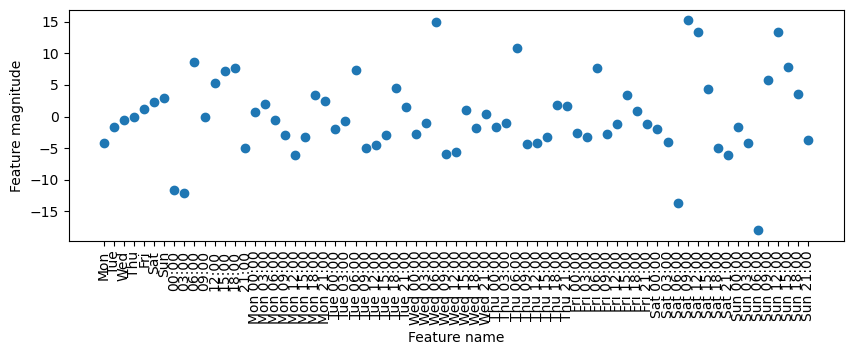

In [ ]:
# 학습한 계수 그래프화
plt.figure(figsize=(10,3))
plt.plot(coef_nonzero, 'o')
plt.xticks(np.arange(len(coef_nonzero)), features_nonzero, rotation=90)
plt.xlabel('Feature name')
plt.ylabel('Feature magnitude')